# Unidad 4 · Máquinas en paralelo: secuenciar es, en realidad, asignar

**Planta:** Conservas del Itata S.A.
**Datos:** `DatosClases/4_Secuenciamiento/itata_paralelas.csv` — 14 lotes y
tres autoclaves
**Solver:** Gurobi

---

## Qué se decide aquí

La planta tiene tres autoclaves. A1 y A2 son gemelos: misma marca, mismo año,
mismo tiempo de ciclo. A3 es una máquina vieja que se conservó como respaldo,
es **24 % más lenta** y su cesta **no admite el formato de 3000 g**.

Esas dos frases cambian el problema de nombre:

| caso | notación | por qué |
|---|---|---|
| solo A1 y A2 | `Pm‖Cmax` | máquinas **idénticas**: `p_j` no depende de la máquina |
| los tres | `Rm‖Cmax` | máquinas **no relacionadas**: `p_jm` depende del par, y además hay **elegibilidad** (algunos pares no existen) |

Entre `Pm` y `Rm` hay un `Qm` intermedio —máquinas **uniformes**, donde
`p_jm = p_j / v_m` con una velocidad `v_m` por máquina— que describiría a A3
si solo fuera más lenta. No lo es: la restricción de formato rompe la
proporcionalidad, porque para los lotes de 3000 g el tiempo en A3 no es
"mayor", es **inexistente**. Por eso hay que ir a `Rm`.

## La idea central

En `Pm‖Cmax` **el orden dentro de cada máquina no afecta el makespan**. Si
una máquina tiene asignados tres lotes, termina en la suma de los tres, los
haga en el orden que los haga. No hay cambios de formato ni liberaciones que
lo alteren.

Luego este no es un problema de secuenciamiento: es un problema de
**partición**. Y eso tiene una consecuencia práctica inmediata. Modelarlo con
variables de secuencia —posiciones, o pares "antes que"— no está mal, está de
más: agrega binarias que no deciden nada y una simetría enorme, porque todas
las permutaciones dentro de una máquina describen el mismo plan. Se mide más
abajo: **392 binarias contra 28**, mismo óptimo.

## Cifras de referencia

| resultado (`Pm‖Cmax`, solo A1 y A2) | valor |
|---|---|
| cota inferior `max(Σp/m, max p)` | **31,35 h** |
| heurística LPT | **31,40 h** |
| óptimo MIP | **31,40 h** |

La garantía de Graham para LPT con `m = 2` es `4/3 − 1/6 = 1,1667`: hasta
16,67 % peor que el óptimo. Aquí LPT **acierta el óptimo exacto**. Una cota
de peor caso no es una predicción.

In [1]:
import sys
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

df = pd.read_csv(datos("4_Secuenciamiento", "itata_paralelas.csv"))

J = list(df.lote)
familia = dict(zip(df.lote, df.familia))
formato = dict(zip(df.lote, df.formato_g))
p_base = dict(zip(df.lote, df.p_base_h))

print(f"{len(J)} lotes · Σ p_base = {sum(p_base.values()):.2f} h")
df

14 lotes · Σ p_base = 62.70 h


,lote,familia,formato_g,p_base_h,p_A1_h,p_A2_h,p_A3_h
0,P01,TOM,480,3.2,3.2,3.2,3.97
1,P02,DUR,480,5.8,5.8,5.8,7.19
2,P03,POR,480,2.4,2.4,2.4,2.98
3,P04,TOM,3000,7.1,7.1,7.1,NaN
4,P05,DUR,820,4.6,4.6,4.6,5.70
5,P06,POR,3000,3.9,3.9,3.9,NaN
6,P07,TOM,480,6.3,6.3,6.3,7.81
7,P08,DUR,480,2.8,2.8,2.8,3.47
8,P09,POR,480,5.1,5.1,5.1,6.32
9,P10,TOM,820,4.2,4.2,4.2,5.21


## 1. Los datos de máquina, y qué significan las celdas vacías

La columna `p_A3_h` viene **vacía** para los lotes de 3000 g. Eso no es un
dato faltante que haya que imputar: es la afirmación de que ese par
lote-máquina **no existe**. La forma correcta de representarlo en el modelo
es no crear la variable `z[j, A3]`, no ponerle un tiempo enorme.

La diferencia importa. Poner "999 horas" deja al solver con la libertad
formal de elegir esa opción y, si el modelo se vuelve infactible por otra
razón, la infactibilidad se disfraza de solución carísima en vez de
reportarse como tal. No crear la variable hace el modelo más chico y la
restricción más honesta.

In [2]:
def construir(maquinas):
    """Devuelve (p_jm, elegibles). Ausente en el CSV = no elegible."""
    p = {}
    for fila in df.itertuples():
        for mq in maquinas:
            v = getattr(fila, f"p_{mq}_h")
            if v is None or (isinstance(v, float) and np.isnan(v)) or v == "":
                continue
            p[(fila.lote, mq)] = float(v)
    eleg = {j: [mq for mq in maquinas if (j, mq) in p] for j in J}
    return p, eleg


p_Rm, eleg_Rm = construir(["A1", "A2", "A3"])
p_Pm, eleg_Pm = construir(["A1", "A2"])

no_elegibles = [j for j in J if "A3" not in eleg_Rm[j]]
razon = (p_Rm[(J[0], "A3")] / p_Rm[(J[0], "A1")] - 1) * 100
print(f"A3 es un {razon:.0f} % más lenta que A1 y A2.")
print(f"A3 no admite {len(no_elegibles)} lotes: "
      + ", ".join(f"{j} ({formato[j]} g)" for j in no_elegibles))
print("\nMáquinas elegibles por lote:")
for j in J:
    print(f"  {j}  {formato[j]:>4} g  ->  {', '.join(eleg_Rm[j])}")

A3 es un 24 % más lenta que A1 y A2.
A3 no admite 2 lotes: P04 (3000 g), P06 (3000 g)

Máquinas elegibles por lote:
  P01   480 g  ->  A1, A2, A3
  P02   480 g  ->  A1, A2, A3
  P03   480 g  ->  A1, A2, A3
  P04  3000 g  ->  A1, A2
  P05   820 g  ->  A1, A2, A3
  P06  3000 g  ->  A1, A2
  P07   480 g  ->  A1, A2, A3
  P08   480 g  ->  A1, A2, A3
  P09   480 g  ->  A1, A2, A3
  P10   820 g  ->  A1, A2, A3
  P11   480 g  ->  A1, A2, A3
  P12   480 g  ->  A1, A2, A3
  P13   480 g  ->  A1, A2, A3
  P14   820 g  ->  A1, A2, A3


## 2. La cota inferior, y de dónde sale

Dos argumentos evidentes, ambos válidos, y la cota buena es la mayor:

$$LB = \max\Big( \frac{\sum_j p_j}{m}, \; \max_j p_j \Big)$$

* **Trabajo total repartido:** aunque las `m` máquinas quedaran perfectamente
  balanceadas, cada una cargaría `Σp/m`. Nadie puede terminar antes.
* **El lote más largo:** alguna máquina tiene que hacerlo entero; no se parte.

Reportar una cota junto al óptimo no es decoración. Sin cota, "el plan dura
31,4 h" no dice si eso es bueno. Con cota, se sabe que el mejor plan
imaginable duraría 31,35 h y que por lo tanto **no queda nada por ganar**:
las 0,05 h de diferencia son indivisibilidad de los lotes, no ineficiencia
del plan.

In [3]:
def cota_inferior(p, eleg, maquinas):
    mejor_p = {j: min(p[(j, mq)] for mq in eleg[j]) for j in J}
    return max(sum(mejor_p.values()) / len(maquinas), max(mejor_p.values()))


LB_Pm = cota_inferior(p_Pm, eleg_Pm, ["A1", "A2"])
LB_Rm = cota_inferior(p_Rm, eleg_Rm, ["A1", "A2", "A3"])

print(f"Pm (A1, A2)     : Σp/m = {sum(p_base.values())/2:.4f}   "
      f"max p = {max(p_base.values()):.2f}   ->  LB = {LB_Pm:.4f} h")
print(f"Rm (A1, A2, A3) : Σp/m = {sum(p_base.values())/3:.4f}   "
      f"max p = {max(p_base.values()):.2f}   ->  LB = {LB_Rm:.4f} h")

Pm (A1, A2)     : Σp/m = 31.3500   max p = 7.10   ->  LB = 31.3500 h
Rm (A1, A2, A3) : Σp/m = 20.9000   max p = 7.10   ->  LB = 20.9000 h


**Cuidado con la segunda línea.** Ese `20,90` se calculó dividiendo el trabajo
total entre tres máquinas, y el argumento que lo justifica —"aunque quedaran
perfectamente balanceadas"— ya no se sostiene:

* A3 tarda 24 % más, así que el trabajo que se le pase **crece** al pasárselo;
  la suma `Σp_j` deja de ser una cantidad fija de trabajo repartible.
* Los dos lotes de 3000 g **no pueden** ir a A3. Ese trabajo se reparte entre
  dos máquinas, no entre tres.

La cota sigue siendo formalmente válida porque se tomó `min_m p_jm` lote a
lote, pero se volvió **floja**: 20,90 contra un óptimo que se verá que es
22,40, un 7 % abajo. La conclusión operativa es que en `Rm` con elegibilidad
hay que buscar otra cota, y la más directa y honesta es la **relajación
lineal del propio modelo**, que se calcula gratis y que se reporta en la
sección 5.

## 3. LPT y la garantía de Graham

LPT (*Longest Processing Time first*): se ordenan los lotes de mayor a menor y
cada uno se manda a la máquina que quede antes libre. La intuición es que los
lotes largos son los que pueden dejar una "cola" desbalanceada al final, así
que conviene colocarlos primero, cuando todavía hay dónde acomodarlos.

Graham (1969) demostró que para `Pm‖Cmax`:

$$\frac{C_{\max}^{LPT}}{C_{\max}^{*}} \;\le\; \frac{4}{3} - \frac{1}{3m}$$

Para `m = 2` eso es `7/6 = 1,1667`, y para `m = 3` es `11/9 = 1,2222`. Es una
garantía de **peor caso**: vale para toda instancia, y por eso es floja en
casi todas. Dos advertencias:

1. La garantía es para máquinas **idénticas**. En `Rm` con elegibilidad no
   aplica, y LPT ni siquiera tiene una cota de aproximación constante.
2. Que LPT respete la cota no dice nada sobre si la alcanzó. Aquí no la
   alcanza ni de lejos.

In [4]:
def lpt(p, eleg, maquinas):
    carga = {mq: 0.0 for mq in maquinas}
    asignado = {mq: [] for mq in maquinas}
    for j in sorted(J, key=lambda z: (-p_base[z], z)):
        mq = min(eleg[j], key=lambda k: (carga[k] + p[(j, k)], k))
        asignado[mq].append(j)
        carga[mq] += p[(j, mq)]
    return {"Cmax": max(carga.values()), "carga": carga, "asignacion": asignado}


lpt_Pm = lpt(p_Pm, eleg_Pm, ["A1", "A2"])
lpt_Rm = lpt(p_Rm, eleg_Rm, ["A1", "A2", "A3"])

print(f"LPT en Pm (A1, A2)     : Cmax = {lpt_Pm['Cmax']:.2f} h   "
      + "  ".join(f"{k}={v:.2f}" for k, v in lpt_Pm["carga"].items()))
print(f"LPT en Rm (A1, A2, A3) : Cmax = {lpt_Rm['Cmax']:.2f} h   "
      + "  ".join(f"{k}={v:.2f}" for k, v in lpt_Rm["carga"].items()))

for m_, lb, sol, etiqueta in [(2, LB_Pm, lpt_Pm, "Pm"), (3, LB_Rm, lpt_Rm, "Rm")]:
    g = 4 / 3 - 1 / (3 * m_)
    print(f"\n{etiqueta}: garantía de Graham para m={m_} es {g:.4f}")
    print(f"   techo que permite la garantía sobre la cota: {g*lb:.2f} h")
    print(f"   LPT entrega: {sol['Cmax']:.2f} h")

LPT en Pm (A1, A2)     : Cmax = 31.40 h   A1=31.30  A2=31.40
LPT en Rm (A1, A2, A3) : Cmax = 22.80 h   A1=22.80  A2=22.40  A3=21.70

Pm: garantía de Graham para m=2 es 1.1667
   techo que permite la garantía sobre la cota: 36.57 h
   LPT entrega: 31.40 h

Rm: garantía de Graham para m=3 es 1.2222
   techo que permite la garantía sobre la cota: 25.54 h
   LPT entrega: 22.80 h


## 4. `Pm‖Cmax`: el modelo es una partición

Si el orden no importa, no hay que modelarlo. Basta una binaria de
**asignación** por par lote-máquina elegible:

$$z_{jm} = 1 \iff \text{el lote } j \text{ se hace en la máquina } m$$

$$\sum_{m \in E(j)} z_{jm} = 1 \quad \forall j \qquad
\sum_j p_{jm} z_{jm} \le C_{\max} \quad \forall m \qquad \min C_{\max}$$

Eso es todo: 28 binarias para 14 lotes y 2 máquinas. No hay variables de
tiempo, no hay big-M, no hay disyunciones. Y como no hay big-M, no hay
relajación floja: la de este modelo va a resultar casi exacta.

**Ruptura de simetría.** Con máquinas idénticas, cualquier permutación de las
máquinas da el mismo `Cmax`: la solución "todo lo de A1 en A2 y viceversa" es
distinta en variables e idéntica en valor. El solver puede pasarse el árbol
entero redescubriendo el mismo plan con otra etiqueta. Fijar el primer lote a
su primera máquina elegible elimina `m!` soluciones equivalentes sin perder
el óptimo. Se resuelve con y sin ella para medirlo — con la advertencia de
que esta instancia es demasiado chica para que se note: el modelo cierra en
el nodo raíz de las dos formas. La ruptura de simetría es una precaución que
se paga sola al crecer `n`, no un truco que rescate instancias pequeñas.

In [5]:
def resolver_asignacion(p, eleg, maquinas, romper_simetria=True,
                        relajado=False, tiempo_limite=60.0):
    m = gp.Model("asignacion-Cmax")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = 1e-9
    m.Params.Seed = 0

    tipo = GRB.CONTINUOUS if relajado else GRB.BINARY
    z = m.addVars([(j, mq) for j in J for mq in eleg[j]], vtype=tipo,
                  lb=0.0, ub=1.0, name="z")
    Cmax = m.addVar(lb=0.0, name="Cmax")

    m.addConstrs((gp.quicksum(z[j, mq] for mq in eleg[j]) == 1 for j in J),
                 name="asignar")
    m.addConstrs((gp.quicksum(p[(j, mq)] * z[j, mq] for j in J if (j, mq) in z)
                  <= Cmax for mq in maquinas), name="carga")
    if romper_simetria and not relajado:
        z[J[0], eleg[J[0]][0]].LB = 1.0

    m.setObjective(Cmax, GRB.MINIMIZE)
    t0 = time.perf_counter()
    m.optimize()
    seg = time.perf_counter() - t0

    asignado = {mq: [] for mq in maquinas}
    if not relajado:
        for (j, mq), v in z.items():
            if v.X > 0.5:
                asignado[mq].append(j)
        for mq in maquinas:
            asignado[mq].sort(key=lambda j: -p[(j, mq)])
    carga = {mq: sum(p[(j, mq)] for j in asignado[mq]) for mq in maquinas}
    return {"modelo": m, "Cmax": m.ObjVal, "carga": carga,
            "asignacion": asignado, "seg": seg,
            "vars": m.NumVars, "binarias": m.NumBinVars,
            "restr": m.NumConstrs, "nodos": int(m.NodeCount),
            "gap_%": 100 * m.MIPGap if not relajado else 0.0,
            "estado": "OPTIMAL" if m.Status == GRB.OPTIMAL else str(m.Status)}


sol_Pm = resolver_asignacion(p_Pm, eleg_Pm, ["A1", "A2"])
sol_Pm_sin = resolver_asignacion(p_Pm, eleg_Pm, ["A1", "A2"],
                                 romper_simetria=False)

print("Pm‖Cmax  (asignación, A1 y A2)")
print(f"  estado        : {sol_Pm['estado']}")
print(f"  óptimo        : {sol_Pm['Cmax']:.4f} h")
print(f"  gap           : {sol_Pm['gap_%']:.6f} %")
print(f"  variables     : {sol_Pm['vars']} ({sol_Pm['binarias']} binarias)")
print(f"  restricciones : {sol_Pm['restr']}")
print(f"  tiempo        : {sol_Pm['seg']:.4f} s")
print(f"  nodos B&B     : {sol_Pm['nodos']}  "
      f"(sin romper simetría: {sol_Pm_sin['nodos']})")
print(f"  carga: " + "  ".join(f"{k}={v:.2f}" for k, v in sol_Pm["carga"].items()))

Restricted license - for non-production use only - expires 2027-11-29


Pm‖Cmax  (asignación, A1 y A2)
  estado        : OPTIMAL
  óptimo        : 31.4000 h
  gap           : 0.000000 %
  variables     : 29 (28 binarias)
  restricciones : 16
  tiempo        : 0.0035 s
  nodos B&B     : 1  (sin romper simetría: 1)
  carga: A1=31.40  A2=31.30


### El modelo que sobra: variables de posición

Para confirmar que el orden no aporta nada, se resuelve el **mismo** problema
con un modelo de secuencia: `z[j, m, k] = 1` si el lote `j` ocupa la posición
`k` de la máquina `m`. Es una formulación perfectamente correcta —de hecho es
la que hace falta si el objetivo fuera `ΣwjCj`, donde la posición sí entra en
la función objetivo— y aquí es puro peso muerto.

In [6]:
def resolver_posiciones(p, eleg, maquinas, tiempo_limite=60.0):
    K = list(range(1, len(J) + 1))
    m = gp.Model("posiciones-Cmax")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = 1e-9
    m.Params.Seed = 0

    z = m.addVars([(j, mq, k) for j in J for mq in eleg[j] for k in K],
                  vtype=GRB.BINARY, name="z")
    Cmax = m.addVar(lb=0.0, name="Cmax")
    m.addConstrs((gp.quicksum(z[j, mq, k] for mq in eleg[j] for k in K) == 1
                  for j in J), name="asignar")
    m.addConstrs((gp.quicksum(z[j, mq, k] for j in J if (j, mq, k) in z) <= 1
                  for mq in maquinas for k in K), name="una_por_posicion")
    m.addConstrs((gp.quicksum(p[(j, mq)] * z[j, mq, k] for j in J for k in K
                              if (j, mq, k) in z) <= Cmax for mq in maquinas),
                 name="carga")
    m.setObjective(Cmax, GRB.MINIMIZE)
    t0 = time.perf_counter()
    m.optimize()
    return {"Cmax": m.ObjVal, "vars": m.NumVars, "binarias": m.NumBinVars,
            "restr": m.NumConstrs, "seg": time.perf_counter() - t0,
            "nodos": int(m.NodeCount)}


pos_Pm = resolver_posiciones(p_Pm, eleg_Pm, ["A1", "A2"])

comp_form = pd.DataFrame([
    {"formulación": "asignación z[j,m]", "Cmax": sol_Pm["Cmax"],
     "variables": sol_Pm["vars"], "binarias": sol_Pm["binarias"],
     "restricciones": sol_Pm["restr"], "segundos": sol_Pm["seg"]},
    {"formulación": "posiciones z[j,m,k]", "Cmax": pos_Pm["Cmax"],
     "variables": pos_Pm["vars"], "binarias": pos_Pm["binarias"],
     "restricciones": pos_Pm["restr"], "segundos": pos_Pm["seg"]},
])
print(comp_form.to_string(index=False, float_format=lambda v: f"{v:,.4f}"))
print(f"\nMismo óptimo, {pos_Pm['binarias'] // sol_Pm['binarias']} veces más "
      f"binarias. Las {pos_Pm['binarias'] - sol_Pm['binarias']} binarias extra")
print("no deciden nada sobre el makespan: para una máquina con k lotes")
print("asignados, las k! formas de repartirlos entre sus posiciones describen")
print("el mismo plan y valen lo mismo.")
# Cuantas variables pide cada formulacion al crecer n, con m = 2 maquinas:
#   asignacion  m*n        posiciones  m*n^2
n_asig = 2000 // 2
n_pos = int((2000 / 2) ** 0.5)
print(f"\nCon m = 2 máquinas, la asignación usa 2n binarias y las posiciones")
print(f"usan 2n². Bajo la licencia de 2000 variables eso da hasta {n_asig} lotes")
print(f"con asignación y solo {n_pos} con posiciones. No es una diferencia de")
print("estilo: es una diferencia de orden de crecimiento.")

        formulación    Cmax  variables  binarias  restricciones  segundos
  asignación z[j,m] 31.4000         29        28             16    0.0035
posiciones z[j,m,k] 31.4000        393       392             44    0.0122

Mismo óptimo, 14 veces más binarias. Las 364 binarias extra
no deciden nada sobre el makespan: para una máquina con k lotes
asignados, las k! formas de repartirlos entre sus posiciones describen
el mismo plan y valen lo mismo.

Con m = 2 máquinas, la asignación usa 2n binarias y las posiciones
usan 2n². Bajo la licencia de 2000 variables eso da hasta 1000 lotes
con asignación y solo 31 con posiciones. No es una diferencia de
estilo: es una diferencia de orden de crecimiento.


## 5. `Rm‖Cmax`: los tres autoclaves, con elegibilidad

El modelo es el mismo. Lo único que cambia son los datos: `p_jm` en vez de
`p_j`, y algunos pares que no existen. Que un cambio de entorno tan
significativo —de idénticas a no relacionadas, más restricciones de
elegibilidad— no obligue a reescribir una sola restricción es una propiedad
de haber elegido las variables correctas.

Sí desaparece la ruptura de simetría: las máquinas ya **no** son
intercambiables, así que fijar el primer lote a A1 podría cortar el óptimo.
Se deja solo cuando corresponde.

In [7]:
sol_Rm = resolver_asignacion(p_Rm, eleg_Rm, ["A1", "A2", "A3"],
                             romper_simetria=False)
lp_Rm = resolver_asignacion(p_Rm, eleg_Rm, ["A1", "A2", "A3"], relajado=True)
lp_Pm = resolver_asignacion(p_Pm, eleg_Pm, ["A1", "A2"], relajado=True)

print("Rm‖Cmax  (asignación con elegibilidad, A1, A2, A3)")
print(f"  estado        : {sol_Rm['estado']}")
print(f"  óptimo        : {sol_Rm['Cmax']:.4f} h")
print(f"  gap           : {sol_Rm['gap_%']:.6f} %")
print(f"  variables     : {sol_Rm['vars']} ({sol_Rm['binarias']} binarias)")
print(f"  restricciones : {sol_Rm['restr']}")
print(f"  tiempo        : {sol_Rm['seg']:.4f} s")
print(f"  nodos B&B     : {sol_Rm['nodos']}")
print(f"  carga: " + "  ".join(f"{k}={v:.2f}" for k, v in sol_Rm["carga"].items()))
print(f"  lotes por máquina: "
      + "  ".join(f"{k}={len(v)}" for k, v in sol_Rm["asignacion"].items()))

print("\nCalidad de las dos cotas inferiores:\n")
print(f"{'caso':6s} {'LB combinatoria':>17s} {'LB relajación LP':>18s} "
      f"{'óptimo':>9s} {'brecha LB comb.':>17s}")
for etiqueta, lb, lp, sol in [("Pm", LB_Pm, lp_Pm["Cmax"], sol_Pm),
                              ("Rm", LB_Rm, lp_Rm["Cmax"], sol_Rm)]:
    print(f"{etiqueta:6s} {lb:17.4f} {lp:18.4f} {sol['Cmax']:9.4f} "
          f"{100*(sol['Cmax']-lb)/sol['Cmax']:16.2f} %")

print("\nEn Pm las dos cotas coinciden y quedan a 0,16 % del óptimo. En Rm la")
print("cota combinatoria se cae a 6,7 % y la relajación lineal del modelo la")
print("reemplaza sin costo: es la cota con la que el solver realmente trabaja.")

Rm‖Cmax  (asignación con elegibilidad, A1, A2, A3)
  estado        : OPTIMAL
  óptimo        : 22.4000 h
  gap           : 0.000000 %
  variables     : 41 (40 binarias)
  restricciones : 17
  tiempo        : 0.7746 s
  nodos B&B     : 3763
  carga: A1=22.30  A2=22.40  A3=22.31
  lotes por máquina: A1=5  A2=5  A3=4

Calidad de las dos cotas inferiores:

caso     LB combinatoria   LB relajación LP    óptimo   brecha LB comb.
Pm               31.3500            31.3500   31.4000             0.16 %
Rm               20.9000            22.3370   22.4000             6.70 %

En Pm las dos cotas coinciden y quedan a 0,16 % del óptimo. En Rm la
cota combinatoria se cae a 6,7 % y la relajación lineal del modelo la
reemplaza sin costo: es la cota con la que el solver realmente trabaja.


## 6. Regla contra óptimo, en los dos entornos

In [8]:
filas = []
for etiqueta, lb, heur, sol, m_ in [
        ("Pm (A1, A2)", LB_Pm, lpt_Pm, sol_Pm, 2),
        ("Rm (A1, A2, A3)", LB_Rm, lpt_Rm, sol_Rm, 3)]:
    filas.append({
        "caso": etiqueta,
        "cota_inferior": lb,
        "LPT": heur["Cmax"],
        "óptimo": sol["Cmax"],
        "exceso_LPT_%": 100 * (heur["Cmax"] / sol["Cmax"] - 1),
        "garantía_Graham_%": 100 * (4 / 3 - 1 / (3 * m_) - 1),
    })
resultados = pd.DataFrame(filas)
print(resultados.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

print("\nEn Pm, LPT acierta el óptimo exacto: 0,00 % de exceso contra una")
print("garantía que permitía 16,67 %. En Rm queda a 1,79 %, y ahí la garantía")
print("de Graham NO aplica: está demostrada para máquinas idénticas, y A3 no")
print("es idéntica ni admite todos los lotes. Que el 1,79 % caiga por debajo")
print("del 22,22 % de la fórmula para m = 3 es una coincidencia de esta")
print("instancia, no una garantía que se pueda invocar.")

           caso  cota_inferior   LPT  óptimo  exceso_LPT_%  garantía_Graham_%
    Pm (A1, A2)          31.35 31.40   31.40          0.00              16.67
Rm (A1, A2, A3)          20.90 22.80   22.40          1.79              22.22

En Pm, LPT acierta el óptimo exacto: 0,00 % de exceso contra una
garantía que permitía 16,67 %. En Rm queda a 1,79 %, y ahí la garantía
de Graham NO aplica: está demostrada para máquinas idénticas, y A3 no
es idéntica ni admite todos los lotes. Que el 1,79 % caiga por debajo
del 22,22 % de la fórmula para m = 3 es una coincidencia de esta
instancia, no una garantía que se pueda invocar.


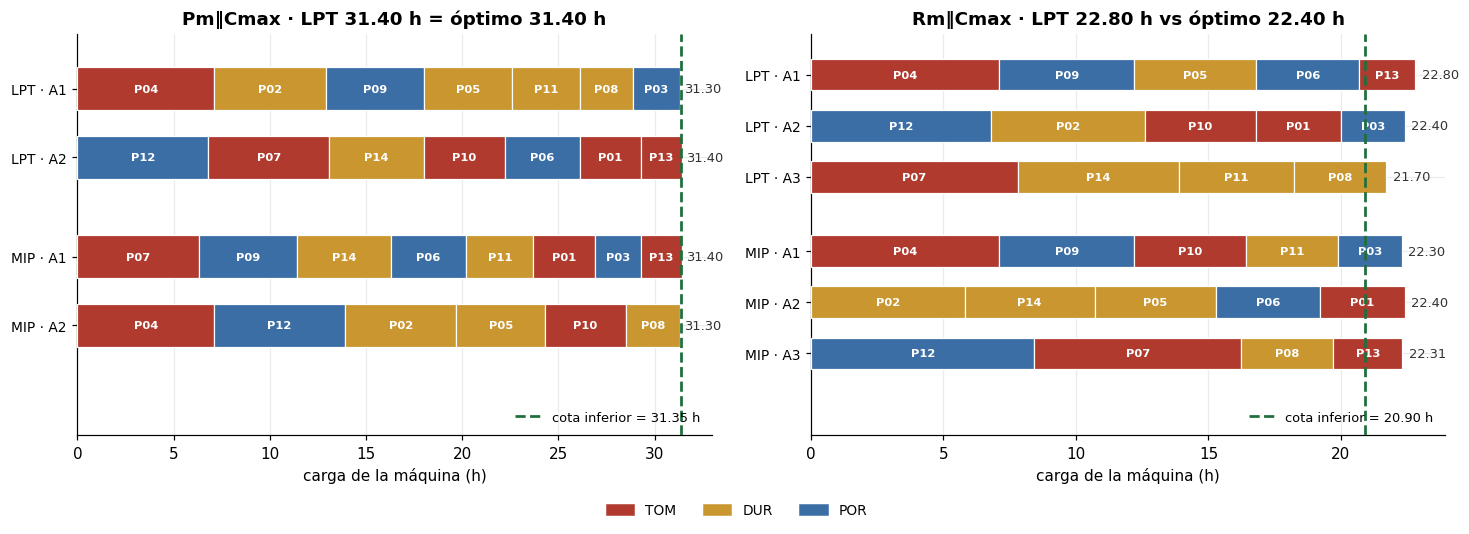

Se ve en el panel derecho lo que hace el óptimo de Rm: las tres cargas
quedan casi iguales (A1=22.30 / A2=22.40 / A3=22.31), contra las de LPT (A1=22.80 / A2=22.40 / A3=21.70).
Para conseguirlo el óptimo le dio a A3 lotes más chicos, porque cada
hora que pasa por A3 cuesta 24 % más y sobrecargarla sale caro. LPT,
que solo mira quién queda antes libre, no ve esa diferencia de costo.


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))

colores_fam = {"TOM": "#b03a2e", "DUR": "#c9962f", "POR": "#3b6ea5"}


def barras_carga(eje, planes, p, maquinas, lb, titulo):
    etiquetas, y = [], 0
    for nombre_plan, asignacion in planes:
        for mq in maquinas:
            izquierda = 0.0
            for j in asignacion[mq]:
                ancho = p[(j, mq)]
                eje.barh(y, ancho, left=izquierda, height=0.62,
                         color=colores_fam[familia[j]], edgecolor="white",
                         linewidth=0.8, zorder=3)
                if ancho > 2.0:
                    eje.text(izquierda + ancho / 2, y, j, ha="center",
                             va="center", color="white", fontsize=7.5,
                             fontweight="bold", zorder=4)
                izquierda += ancho
            eje.text(izquierda + 0.25, y, f"{izquierda:.2f}", va="center",
                     fontsize=8.5, color="#333333")
            etiquetas.append(f"{nombre_plan} · {mq}")
            y += 1
        y += 0.45
    posiciones = []
    y = 0
    for _ in planes:
        for _ in maquinas:
            posiciones.append(y)
            y += 1
        y += 0.45
    eje.set_yticks(posiciones)
    eje.set_yticklabels(etiquetas, fontsize=9)
    # Se invierte el eje a mano dejando una franja libre abajo para la leyenda,
    # en vez de invert_yaxis(), que la dejaría encima de la última barra.
    eje.set_ylim(posiciones[-1] + 1.6, -0.8)
    eje.axvline(lb, color="#1f6f3d", lw=1.8, ls="--", zorder=5,
                label=f"cota inferior = {lb:.2f} h")
    eje.set_xlabel("carga de la máquina (h)")
    eje.set_title(titulo)
    eje.legend(fontsize=8.5, loc="lower right")
    eje.grid(axis="x", alpha=0.25)


barras_carga(ax[0], [("LPT", lpt_Pm["asignacion"]), ("MIP", sol_Pm["asignacion"])],
             p_Pm, ["A1", "A2"], LB_Pm,
             f"Pm‖Cmax · LPT {lpt_Pm['Cmax']:.2f} h = óptimo {sol_Pm['Cmax']:.2f} h")
barras_carga(ax[1], [("LPT", lpt_Rm["asignacion"]), ("MIP", sol_Rm["asignacion"])],
             p_Rm, ["A1", "A2", "A3"], LB_Rm,
             f"Rm‖Cmax · LPT {lpt_Rm['Cmax']:.2f} h vs óptimo {sol_Rm['Cmax']:.2f} h")

manijas = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colores_fam.values()]
fig.legend(manijas, list(colores_fam), ncol=3, fontsize=9,
           loc="lower center", bbox_to_anchor=(0.5, -0.06))

figura(fig, "carga_por_maquina")
plt.show()

print("Se ve en el panel derecho lo que hace el óptimo de Rm: las tres cargas")
print("quedan casi iguales ("
      + " / ".join(f"{k}={v:.2f}" for k, v in sol_Rm["carga"].items())
      + f"), contra las de LPT ("
      + " / ".join(f"{k}={v:.2f}" for k, v in lpt_Rm["carga"].items()) + ").")
print("Para conseguirlo el óptimo le dio a A3 lotes más chicos, porque cada")
print("hora que pasa por A3 cuesta 24 % más y sobrecargarla sale caro. LPT,")
print("que solo mira quién queda antes libre, no ve esa diferencia de costo.")

## 7. El plan, lote por lote

In [10]:
filas = []
for mq in ["A1", "A2", "A3"]:
    t = 0.0
    for orden, j in enumerate(sol_Rm["asignacion"][mq], start=1):
        ini = t
        t += p_Rm[(j, mq)]
        filas.append({"maquina": mq, "orden": orden, "lote": j,
                      "familia": familia[j], "formato_g": formato[j],
                      "p_h": p_Rm[(j, mq)], "inicio": ini, "fin": t})
plan_Rm = pd.DataFrame(filas)
print(plan_Rm.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

print("\nEl orden de la columna 'orden' es arbitrario: se listó por tiempo")
print("decreciente porque hay que listarlo de alguna forma. Cualquier otro")
print("orden dentro de la misma máquina da EXACTAMENTE el mismo Cmax. Eso es")
print("lo que significa que el problema sea de asignación y no de secuencia.")

# Se comprueba, en vez de afirmarse.
import itertools
rng = np.random.default_rng(0)
cmax_permutados = []
for _ in range(200):
    total = 0.0
    for mq in ["A1", "A2", "A3"]:
        lotes = list(sol_Rm["asignacion"][mq])
        rng.shuffle(lotes)
        total = max(total, sum(p_Rm[(j, mq)] for j in lotes))
    cmax_permutados.append(round(total, 9))
print(f"\n200 permutaciones aleatorias dentro de cada máquina produjeron "
      f"{len(set(cmax_permutados))} valor distinto de Cmax: "
      f"{set(cmax_permutados)}")

maquina  orden lote familia  formato_g  p_h  inicio   fin
     A1      1  P04     TOM       3000 7.10    0.00  7.10
     A1      2  P09     POR        480 5.10    7.10 12.20
     A1      3  P10     TOM        820 4.20   12.20 16.40
     A1      4  P11     DUR        480 3.50   16.40 19.90
     A1      5  P03     POR        480 2.40   19.90 22.30
     A2      1  P02     DUR        480 5.80    0.00  5.80
     A2      2  P14     DUR        820 4.90    5.80 10.70
     A2      3  P05     DUR        820 4.60   10.70 15.30
     A2      4  P06     POR       3000 3.90   15.30 19.20
     A2      5  P01     TOM        480 3.20   19.20 22.40
     A3      1  P12     POR        480 8.43    0.00  8.43
     A3      2  P07     TOM        480 7.81    8.43 16.24
     A3      3  P08     DUR        480 3.47   16.24 19.71
     A3      4  P13     TOM        480 2.60   19.71 22.31

El orden de la columna 'orden' es arbitrario: se listó por tiempo
decreciente porque hay que listarlo de alguna forma. Cualquier 

## 8. Comprobación

In [11]:
print("Comprobación:")
ok = []
ok.append(verificar(LB_Pm, 31.35, "Pm · cota inferior (h)", tol=1e-9))
ok.append(verificar(lpt_Pm["Cmax"], 31.40, "Pm · LPT (h)", tol=1e-9))
ok.append(verificar(sol_Pm["Cmax"], 31.40, "Pm · óptimo MIP (h)", tol=1e-9))
ok.append(verificar(pos_Pm["Cmax"], 31.40,
                    "Pm · óptimo con variables de posición (h)", tol=1e-9))
ok.append(verificar(sol_Rm["Cmax"], 22.40, "Rm · óptimo MIP (h)", tol=1e-9))
ok.append(verificar(lpt_Rm["Cmax"], 22.80, "Rm · LPT (h)", tol=1e-9))
print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

# La cota inferior tiene que serlo.
assert LB_Pm <= sol_Pm["Cmax"] + 1e-9, "la cota de Pm debe estar bajo el óptimo"
assert LB_Rm <= sol_Rm["Cmax"] + 1e-9, "la cota de Rm debe estar bajo el óptimo"
# Las dos formulaciones de Pm dan el mismo optimo con muy distinto tamanio.
assert abs(pos_Pm["Cmax"] - sol_Pm["Cmax"]) < 1e-6, \
    "asignación y posiciones deben dar el mismo óptimo"
assert pos_Pm["binarias"] > 10 * sol_Pm["binarias"], \
    "el modelo por posiciones debería ser un orden de magnitud mayor"
# La garantia de Graham se respeta en Pm (y con enorme holgura).
assert lpt_Pm["Cmax"] <= (4/3 - 1/6) * sol_Pm["Cmax"] + 1e-9, \
    "LPT no puede violar la garantía de Graham en Pm"
# El orden dentro de cada maquina no cambia el makespan.
assert len(set(cmax_permutados)) == 1, \
    "en Pm/Rm sin setups el orden dentro de la máquina no puede cambiar Cmax"
# Elegibilidad respetada: ningun lote de 3000 g en A3.
assert all(formato[j] != 3000 for j in sol_Rm["asignacion"]["A3"]), \
    "A3 no admite el formato de 3000 g"

tabla(resultados, "paralelas_lpt_vs_optimo")
tabla(plan_Rm, "paralelas_plan_Rm")
tabla(comp_form, "paralelas_formulaciones")
resumen({"Pm_cota_inferior": float(LB_Pm), "Pm_LPT": float(lpt_Pm["Cmax"]),
         "Pm_optimo": float(sol_Pm["Cmax"]),
         "Rm_cota_inferior": float(LB_Rm), "Rm_LPT": float(lpt_Rm["Cmax"]),
         "Rm_optimo": float(sol_Rm["Cmax"]),
         "Rm_cota_LP": float(lp_Rm["Cmax"]),
         "binarias_asignacion": sol_Pm["binarias"],
         "binarias_posiciones": pos_Pm["binarias"],
         "carga_Rm": {k: float(v) for k, v in sol_Rm["carga"].items()}},
        "resumen_paralelas")
print("\nGuardado en resultados/")

Comprobación:
  [  OK  ] Pm · cota inferior (h): obtenido 31.3500 | referencia 31.3500 | dif. relativa 1.13e-16
  [  OK  ] Pm · LPT (h): obtenido 31.4000 | referencia 31.4000 | dif. relativa 0.00e+00
  [  OK  ] Pm · óptimo MIP (h): obtenido 31.4000 | referencia 31.4000 | dif. relativa 0.00e+00
  [  OK  ] Pm · óptimo con variables de posición (h): obtenido 31.4000 | referencia 31.4000 | dif. relativa 0.00e+00
  [  OK  ] Rm · óptimo MIP (h): obtenido 22.4000 | referencia 22.4000 | dif. relativa 0.00e+00
  [  OK  ] Rm · LPT (h): obtenido 22.8000 | referencia 22.8000 | dif. relativa 1.56e-16

6/6 comprobaciones correctas

Guardado en resultados/


---

## Para llevarse

1. **Secuenciar es, aquí, asignar.** En `Pm‖Cmax` y `Rm‖Cmax` sin cambios ni
   liberaciones, el orden dentro de cada máquina es irrelevante. Modelarlo
   con variables de secuencia multiplica las binarias por catorce y agrega una
   simetría factorial, y no mejora nada. Antes de escribir una variable, hay
   que preguntarse qué decide.
2. **Una celda vacía es un dato, no un dato faltante.** `p_A3 = ∅` para los
   lotes de 3000 g significa "no elegible", y se modela **no creando la
   variable**. Ponerle un número grande convierte una imposibilidad física en
   una opción cara, y las infactibilidades dejan de reportarse como tales.
3. **Una cota de peor caso no es una predicción.** Graham garantiza 16,67 %
   para LPT con dos máquinas, y LPT acierta el óptimo. La garantía sirve para
   saber qué no puede pasar, no para estimar qué va a pasar.
4. **Cambiar de entorno cambia qué cotas valen.** `max(Σp/m, max p)` es
   natural en `Pm` y queda floja en cuanto hay elegibilidad y velocidades
   distintas, porque su argumento —trabajo fijo repartible entre `m`
   máquinas— deja de describir el problema. La relajación lineal del modelo
   la reemplaza y no cuesta nada.
5. **Las cotas se reportan siempre.** "El plan dura 31,4 h" no dice si es
   bueno. "El plan dura 31,4 h y ningún plan puede durar menos de 31,35 h"
   cierra la discusión.

## Ejercicios

1. Suponga que la planta arrienda un cuarto autoclave idéntico a A1. Resuelva
   `P3‖Cmax` con A1, A2 y el nuevo, y compare con `Rm` de tres máquinas.
   ¿Cuánto vale tener una máquina rápida más en vez de la vieja A3?
2. Cambie el objetivo a `ΣwjCj` (asigne pesos que le parezcan razonables).
   Ahora el orden **sí** importa, y el orden óptimo dentro de cada máquina es
   WSPT. Formule con variables de posición contadas **desde el final**: si un
   lote ocupa la `k`-ésima posición desde el final, su `p` entra `k` veces en
   la suma. ¿Por qué desde el final y no desde el principio?
3. Agregue tiempos de cambio dependientes de la familia dentro de cada
   máquina. ¿Sigue siendo cierto que el orden no importa? ¿Qué pasa con la
   formulación de asignación?
4. Reemplace la elegibilidad por un tiempo de 999 h para los lotes de 3000 g
   en A3 y vuelva a resolver. ¿Cambia el óptimo? Ahora quite un autoclave y
   vea qué reporta el solver en cada versión del modelo. ¿Cuál de las dos le
   avisa que el problema no tiene solución?
5. Con 14 lotes y 3 máquinas hay `3^14 ≈ 4,8` millones de asignaciones, y el
   solver resolvió en centésimas de segundo explorando unos miles de nodos.
   ¿Por qué? Mire la cota de la relajación lineal de la sección 5 y explique
   qué le permite podar.